# Machine Learning - Spring 2026
## Homework 2

Instructor: Dr. Ilia Tetin


Student ID: 11461316A

Student Name: Christian R. Marcos

In [1]:
import shutil

shutil.copy('/kaggle/input/datasets/christianmarcos/homework-2/descents.py', '/kaggle/working/descents.py')
shutil.copy('/kaggle/input/datasets/christianmarcos/homework-2/linear_regression.py', '/kaggle/working/linear_regression.py')

'/kaggle/working/linear_regression.py'

In [2]:
import numpy as np
import sklearn
from linear_regression import MSELoss, CustomLinearRegression, AnalyticSolutionOptimizer
from sklearn.metrics import mean_squared_error as mse


### About the assignment

In this task, you will implement the training of a linear regression model using several variants of gradient-based optimization. In `descents.py`, you are expected to complete a set of classes corresponding to different optimization strategies:

* `VanillaGradientDescent`
* `StochasticGradientDescent`
* `SAGDescent`
* `MomentumDescent`
* `Adam`

In `linear_regression.py`, you will need to implement the `CustomLinearRegression` class, which will handle both fitting the linear regression model and generating predictions for the target variable based on the learned parameters.

### About the proposed architecture

The provided template structure follows SOLID-style design principles. Its main advantage is that you can combine different loss functions and optimizers without rewriting the surrounding logic of the other classes. This is achieved by separating responsibilities clearly and relying on interfaces rather than hard-coded implementations. In Python, these interfaces are represented through abstract base classes.

At a high level, the architecture consists of four main interfaces (some of which are also represented directly by concrete base classes), each defining its own family of components:

* `interfaces.LossFunction`
  Classes implementing this interface are responsible for a specific loss function used during training, along with all behavior tied to that choice: loss computation, gradient calculation, and, when applicable, an analytical solution provided through an appropriate mixin.

* `interfaces.LinearRegressionInterface`
  This is the wrapper interface for the linear regression model itself. It acts as a container that combines the main components (the loss function and the optimizer) and uses them to perform the actual training and prediction workflow.

* `interfaces.LearningRateSchedule`
  A small family of schedules that determine the learning rate at each optimization step.

* `interfaces.AbstractOptimizer`
  Classes implementing this interface define a particular optimization algorithm and everything related to its execution. They interact with the linear regression wrapper to access the data and trigger the necessary computations, which keeps them independent of any specific loss function or learning-rate schedule.

The idea of passing small, self-contained objects into a more complex object so that each one handles its own narrow responsibility is known as **dependency injection**. This works effectively because each component is built around a well-defined interface rather than a specific implementation.

Take a look at `linear_regression.CustomLinearRegression`: it accepts objects implementing the `LossFunction` and `AbstractOptimizer` interfaces. In turn, `descents.BaseDescent`, which refines the abstract optimizer into an iterative optimization base class, receives a learning-rate scheduler during initialization.

Because of this structure, client code can proceed step by step:

* create the desired learning-rate scheduler with the required parameters;
* create the optimizer, passing in its configuration together with the scheduler;
* create the linear regression model with the appropriate loss function and the prepared optimizer;
* start the training process.

At each stage, one component can be replaced with another compatible implementation, and the rest of the system will continue to work seamlessly.

**As you work through this assignment, you will extend all of these class families with multiple implementations and swap them in and out with ease.**

For a more detailed overview of class inheritance in Python, see:

* Inheritance: `https://docs.python.org/3/tutorial/classes.html#inheritance`
* Abstract classes: `https://docs.python.org/3/library/abc.html`


### Gradient of the MSE Loss Function

In the seminar on matrix and vector differentiation, you were expected to discuss how to differentiate the MSE loss in matrix form.

### Task 1.0. MSE Gradient in Matrix Form (0.3 points)

Recall that the MSE loss can be written as

$$
Q(w) = \frac{1}{\ell} \sum_{i=1}^{\ell} (y_i - \langle x_i, w \rangle)^2
= \frac{1}{\ell} |Xw - y|^2
$$

where $\ell$ is the number of training samples, $X \in \mathbb{R}^{\ell \times d}$ is the feature matrix, and $y \in \mathbb{R}^{\ell}$ is the target vector. The notation $x_i$ refers to the $i$-th row of $X$, corresponding to the $i$-th sample.

* **Write down the gradient of the MSE loss in matrix form** (either from the seminar notes or by deriving it yourself).

**Solution:**

---
---
`### write your solution here ###`


**Solution:**

Expand the squared norm:

$$Q(w) = \frac{1}{\ell}(Xw - y)^\top(Xw - y) = \frac{1}{\ell}\left(w^\top X^\top X w - 2y^\top X w + y^\top y\right)$$

Differentiating term by term with respect to $w$:

$$\nabla_w Q(w) = \frac{2}{\ell}\,X^\top(Xw - y)$$

---
---

* **Implement the methods `MSELoss.loss` and `MSELoss.gradient`**

### Task 1.1. Closed-Form Solution and `CustomLinearRegression` (0.7 points)

Before moving on to iterative optimization methods, let us recall that for some loss functions an analytical solution also exists. First, let us revisit what that solution looks like for MSE.

* **Derive the formula for the optimal $w$ in the MSE minimization problem and write it below.**
* **Implement this computation in `MSELoss._plain_analytic_solution`**

$$
\text{MSE} = |Xw - y|^2
$$

$$
w =
$$

---
---
$$w^* = (X^\top X)^{-1} X^\top y$$

**Derivation:** Set the gradient to zero:

$$ 2 X^\top (Xw - y) = 0 \implies X^\top X\, w = X^\top y \implies w^* = (X^\top X)^{-1} X^\top y$$

---
---

* **Question:** As we know, the analytical solution has several drawbacks. What are they?

**Answer:** 

---
---
`# write your answer here`

1. **Computational cost** — inverting $X^\top X$ costs $O(d^3)$, which is prohibitively slow for large feature dimensions.
2. **Numerical instability** — if $X^\top X$ is ill-conditioned, inverting it amplifies floating-point errors and gives unreliable results. and; **Non-invertibility** — if $X$ is rank-deficient (e.g. multicollinear features), $X^\top X$ is singular and the formula breaks entirely.
---
---

Now let us connect this solution to our linear regression class so that the overall architecture becomes clearer.

* **Complete the class `descents.AnalyticSolutionOptimizer`**
* **Complete the class `CustomLinearRegression`**

  * At this stage, you should implement all of its methods: `fit` and `predict` will be needed immediately, while `compute_gradients` and `compute_loss` will be used in the next part.

Keep in mind the separation of responsibilities between classes.

The optimizer is responsible for controlling the training procedure, while the linear regression object mainly serves as an entry point, a container for the data, and an access layer for the computations that the optimizer relies on, such as the gradient direction at the current parameter values.

At the same time, the optimizer itself should remain generic: it should not contain any logic specific to a particular loss function. Everything it needs should be accessible through `self.model`.

Similarly, the linear regression class should also remain generic and be ready to work with any loss function and any optimizer that follows the required interface. This is an example of dependency injection, and your implementation should preserve that design properly. In the same way, anything your model needs from the loss function should be obtained by calling the corresponding methods of the injected loss object.


In [3]:
num_objects = 100
dimension = 5

x = np.random.rand(num_objects, dimension)
y = np.random.rand(num_objects)

sklearn_linreg = sklearn.linear_model.LinearRegression(fit_intercept=False)
sklearn_linreg.fit(x, y)
print("Sklearn MSE", mse(sklearn_linreg.predict(x), y))

your_linreg = CustomLinearRegression(AnalyticSolutionOptimizer(), loss_function=MSELoss())
your_linreg.fit(x, y)
print("Your MSE", mse(your_linreg.predict(x), y))

assert abs(mse(your_linreg.predict(x), y) - mse(sklearn_linreg.predict(x), y)) < 1e-12, "try again"

Sklearn MSE 0.1210495383877435
Your MSE 0.12104953838774347


In [4]:
x[:, 3] = x[:, 2] + x[:, 4]

In [5]:
sklearn_linreg = sklearn.linear_model.LinearRegression(fit_intercept=False)
sklearn_linreg.fit(x, y)
print("Sklearn MSE", mse(sklearn_linreg.predict(x), y))

your_linreg = CustomLinearRegression(AnalyticSolutionOptimizer(), loss_function=MSELoss())
your_linreg.fit(x, y)
print("Your MSE", mse(your_linreg.predict(x), y))

Sklearn MSE 0.1278633650508559
Your MSE 0.1278633650508559


Let’s make this part a bit more interesting by modifying one of the assumptions. As we know, exact multicollinearity prevents us from using the standard closed-form solution directly, yet `sklearn` somehow still manages to handle such cases. Your goal is to figure out how to make the analytical solution well-defined for **any** matrix $X$, regardless of rank deficiency. It turns out this can be done using an SVD-based formulation. For the implementation, use `scipy.sparse.linalg.svds`.

* Derive the SVD-based expression for the optimal $w$ in the MSE minimization problem.

* Implement this computation in `MSELoss._svd_analytic_solution`.

  * Numerical linear algebra can be tricky. If you inspect the available options in `svds`, you will notice that computing the full spectrum with exact precision is not really the intended use case. Use the default solver and set the highest available numerical accuracy.

* Answer the **bonus theory question**. In some settings, including this one, even an apparently imperfect SVD computation can still recover the exact solution to the problem. Explain why this happens. What is this variant of SVD called? What is the minimum number of singular values that is sufficient, with probability 1, to recover the exact solution in our case? Justify your answer.

$$
X = \underset{n \times m}{U}\ \underset{m \times m}{\Sigma}\ \underset{m \times k}{V^T}
$$

$$
w =
$$

**Answer:** 

---
---
`# write your answer here`

$$X = U\,\Sigma\,V^\top$$

$$w^* = V\,\Sigma^{-1}\,U^\top\,y$$

**Derivation:** The minimum-norm least-squares solution is given by the Moore-Penrose pseudoinverse $w^* = X^+ y$. Using the thin SVD $X = U\Sigma V^\top$ where only the $r = \text{rank}(X)$ non-zero singular values are kept, the pseudoinverse is $X^+ = V\Sigma^{-1}U^\top$, so $w^* = V\Sigma^{-1}U^\top y$.

**Answer for the bonus question:**

This variant is called the **truncated SVD** (economy / thin SVD). It computes only the $r$ largest singular values rather than the full spectrum.

In our rank-deficient case (column 3 = column 2 + column 4), the rank of $X$ is $d - 1 = 4$. The pseudoinverse is entirely determined by those $r$ non-zero singular values and their corresponding singular vectors — the zero singular value contributes nothing to $w^*$.

Therefore the **minimum number of singular values sufficient to recover the exact solution with probability 1 is $r = \text{rank}(X) = 4$**. Even though `svds` cannot compute all $\min(n,d)$ singular values, it recovers the exact minimum-norm solution because the missing singular value is zero and drops out of the pseudoinverse.

---
---

In [6]:
sklearn_linreg = sklearn.linear_model.LinearRegression(fit_intercept=False)
sklearn_linreg.fit(x, y)
print("Sklearn MSE", mse(sklearn_linreg.predict(x), y))


your_linreg =  CustomLinearRegression(AnalyticSolutionOptimizer(),
                                      loss_function=MSELoss(analytic_solution_func=MSELoss._svd_analytic_solution))
your_linreg.fit(x, y)

print("Your MSE", mse(your_linreg.predict(x), y))

assert abs(mse(your_linreg.predict(x), y) - mse(sklearn_linreg.predict(x), y)) < 1e-12, "try again"

Sklearn MSE 0.1278633650508559
Your MSE 0.12786336505085588


## Task 2. Implementing Gradient Descent (4 points)

In this part, you will build your own implementations of several gradient-based optimization methods using the prepared templates in `descents.py`. These optimizers will then be plugged into `CustomLinearRegression` to obtain iterative solutions.

### Reminder: gradient descent

The key property of the negative gradient is that it points in the direction of the **steepest decrease** of the objective at the current point. Naturally, this suggests the following strategy: start from some initial parameter vector, move in the direction of the negative gradient, recompute it at the new point, and repeat until convergence.

Formally, let $w_0$ be the initial parameter vector (for example, zeros or a random initialization). Then vanilla gradient descent consists of repeating

$$
w_{k+1} = w_k - \eta_k \nabla_w Q(w_k).
$$

Here, $\eta_k$ is the step size at iteration $k$ (the learning rate), and $Q(w)$ is the loss function.

You have already derived the gradient of MSE above.

### Task 2.0. Learning Rate Schedules (0.2 points)

Take a look at the **abstract** class `LearningRateSchedule` in `descents.py`. Its implementations are used to produce the appropriate learning rate $\eta_k$ at each iteration of gradient descent.

The file already includes `ConstantLR`, which returns the same fixed step size every time. Your task here is to implement `TimeDecayLR`, which we will use for linear regression training. The step size should follow

$$
\eta_k = \lambda \left(\frac{s_0}{s_0 + k}\right)^p
$$

In practice, it is usually enough to tune only $\lambda$, while keeping the default values $s_0 = 1$ and $p = 0.5$.





### Task 2.1. The parent class `BaseDescent` (1 point)

Study the structure of `BaseDescent` carefully. Although it is an abstract base for iterative optimizers, it still contains one method that must be implemented: `optimize`.

* **Complete the method `BaseDescent.optimize`.**

This method should contain the main optimization loop, which will then be reused by all subclasses.

For this part and everything that follows, the implementation must satisfy these requirements:

* **All computations must be vectorized;**
* Python loops are allowed only for the outer optimization iterations;
* Use the following stopping criteria simultaneously:

  * the squared Euclidean norm of the difference between consecutive weight vectors is smaller than `tolerance`;
  * the weight difference contains `NaN` values;
  * the number of iterations reaches `max_iter`.
* You may assume that the input data already contains a column of ones as the last feature column;
* Model weights must be updated inside `_update_weights` — that method name is intentional;
* To monitor convergence, use `CustomLinearRegression.loss_history`, storing:

  * the loss value **before each update**, starting from iteration zero (before the first gradient step),
  * and the final loss value **after optimization finishes**.

Note that `_update_weights` is still abstract, so it must be implemented by the subclasses. Its role is to update `self.model.w` and return the actual update vector

$$
w_{k+1} - w_k.
$$

Also pay attention to `self.iteration`, which stores the current iteration number. Together with `self.lr_schedule`, it is used to obtain the correct learning rate for each step.

### Important note

Yes, one more time:

All descent classes you implement in this assignment are meant to be **generic optimizers**. They must not compute gradients of a specific loss function internally.

Whenever an optimizer needs a gradient, it should always ask the model:

```python
gradient = self.model.compute_gradients(X_batch, y_batch)
```

### Task 2.2. Full gradient descent: `VanillaGradientDescent` (0.6 points)

Implement full-batch gradient descent by filling in the missing parts of `VanillaGradientDescent` in `descents.py`.

Recall that the update rule for classical gradient descent is

$$
w_{k+1} = w_k - \eta_k \nabla_w Q(w_k).
$$

**Important:** here and below, `_update_weights` must return the difference between the new and old weights:

$$
w_{k+1} - w_k = -\eta_k \nabla_w Q(w_k).
$$

As its name suggests, it must also update `model.w`.

### Reminder: SGD (stochastic gradient descent)

In many machine learning problems, the objective $Q(w)$ can be written as a sum of $\ell$ terms:

$$
Q(w) = \frac{1}{\ell} \sum_{i=1}^{\ell} q_i(w).
$$

In our assignment, each function $q_i(w)$ corresponds to the error contribution of a single training example.

The drawback of standard gradient descent is that each step requires computing the gradient of the full sum:

$$
\nabla_w Q(w) = \frac{1}{\ell} \sum_{i=1}^{\ell} \nabla_w q_i(w).
$$

For large datasets, this can be expensive. In practice, however, an exact gradient is often unnecessary: since the update step is usually not too large, a noisy approximation often works well enough.

A common approximation is to average gradients over a randomly chosen subset of samples:

$$
\nabla_w Q(w_k) \approx \frac{1}{|B|} \sum_{i \in B} \nabla_w q_i(w_k),
$$

where $B$ is a random subset of indices, usually called a **batch**.

This estimate is known as a **stochastic gradient**, and the resulting method is called **stochastic gradient descent**, or simply SGD.

### Task 2.3. Stochastic gradient descent: `StochasticGradientDescent` (0.7 points)

Implement stochastic gradient descent by completing the missing parts of `StochasticGradientDescent`.

Use the mini-batch gradient estimate above. The update rule becomes

$$
w_{k+1} = w_k - \eta_k \frac{1}{|B|} \sum_{i \in B} \nabla_w q_i(w_k).
$$

The batch size should be treated as a **hyperparameter** and passed through the class constructor `__init__(...)`.

You may sample batch indices with replacement using `np.random.randint` — this is acceptable and yields an unbiased gradient estimate. Sampling without replacement is also fine, for example via `np.random.choice(..., replace=False)` or by shuffling across epochs.


### Task 2.4. Stochastic Average Gradient (0.6 points)
Now consider the SAG method. We keep in memory the most recent individual gradients $g_i$ for all training examples, as well as their average

$$
\bar g = \frac{1}{\ell} \sum_i g_i.
$$

At each step, we choose indices $j$ (a mini-batch), recompute the corresponding gradients $g_j^{new}(w_k)$, and update the running average as

$$
\bar g \leftarrow \bar g + \frac{1}{\ell}\bigl(g_j^{new} - g_j^{old}\bigr), \qquad
w_{k+1} = w_k - \eta_k \bar g.
$$

Initialization is

$$
g_i = 0 \Rightarrow \bar g = 0.
$$

This gives us updates that resemble full-gradient descent, while only recomputing gradients for a small number of samples on each iteration.

Implement `SAGDescent` in `descents.py` using `grad_memory` and `avg_grad`.

A useful trick: to obtain a per-sample gradient, you can call `compute_gradients` either on a slice containing a single sample, `X[j:j+1]`, or on a matrix formed from the selected batch indices.

**Keep in mind that SAG can be quite sensitive**: its convergence and practical speed depend noticeably on the batch size. A default value is provided, but on real datasets it may not be enough. In later comparisons, you may need to tune the batch size to see the method perform well. The same applies to SGD, although usually to a lesser extent.

### A quick reminder: Momentum (inertia) method

Sometimes the negative gradient direction changes too sharply from one step to the next. For instance, if the level sets of the objective are highly elongated, then because the gradient is orthogonal to those level sets, its direction may flip almost to the opposite side at every iteration. Such oscillations add a lot of noise to the trajectory and slow optimization down significantly.

To reduce this effect, we can average the negative gradients from several previous steps. This smooths out the noise and makes the update direction reflect the overall trend of motion more accurately. For that, we introduce the **momentum vector**:

\begin{align}
&h_0 = 0, \
&h_{k+1} = \alpha h_k + \eta_k \nabla_w Q(w_k)
\end{align}

Here, $\alpha$ is the momentum coefficient controlling how quickly information from previous steps decays. Naturally, instead of the exact gradient, one may also use its approximation, for example in the case of **stochastic gradient descent**.

Then the parameter update is simply performed by moving against the new momentum vector:

$$
w_{k+1} = w_k - h_{k+1}.
$$

Notice that if the gradient along a certain coordinate keeps changing sign, then after averaging, that coordinate of the momentum vector will tend to stay close to zero. On the other hand, if the gradient along some coordinate consistently keeps the same sign, then the corresponding momentum component will grow larger, leading to bigger steps in that direction.



### Task 2.5. Momentum method — `MomentumDescent` (0.5 points)

Implement gradient descent with momentum by filling in the missing parts of the `MomentumDescent` class. The update rule is

\begin{align}
&h_0 = 0, \
&h_{k+1} = \alpha h_k + \eta_k \nabla_w Q(w_k), \
&w_{k+1} = w_k - h_{k+1}.
\end{align}

The parameter $\alpha$ is a hyperparameter of the method, but in this assignment it is fixed for you at $\alpha = 0.9$.

### A quick reminder: AdaGrad, RMSProp, and Adam

Gradient descent is highly sensitive to the choice of step size. If the step is too large, the algorithm may overshoot the minimum; if it is too small, convergence may take far too many iterations. Moreover, there is usually no reliable way to know the optimal learning rate in advance, and even schedules that gradually shrink it can behave poorly.

In **AdaGrad**, a separate effective step size is introduced for each coordinate of the parameter vector. The idea is simple: accumulate the sum of squared gradients and divide the current gradient by the square root of that sum. As a result, coordinates with consistently large gradients get smaller updates, while coordinates with smaller gradients receive relatively larger ones. The update rule is

\begin{align}
&G_{k j} = G_{k-1, j} + \left(\nabla_w Q(w_{k-1})\right)*j^2, \
&w*{j k} = w_{j, k-1} - \frac{\eta_k}{\sqrt{G_{k j}} + \varepsilon} \left(\nabla_w Q(w_{k-1})\right)_j.
\end{align}

Here, $\varepsilon$ is a small constant used to prevent division by zero.

In this method, it is often possible to keep the learning rate fixed, for example $\eta_k = 0.01$, rather than tuning it during training **(note that in this assignment, the learning rate is not fixed)**. AdaGrad is especially useful for sparse problems, where most features are zero for most samples. Features that appear only rarely receive relatively large updates, while frequently active features get smaller ones.

However, AdaGrad has a major drawback: the accumulator $G_{k j}$ grows monotonically, so the updates become smaller and smaller over time, potentially stopping progress before the true minimum is reached.

This issue is addressed in **RMSProp**, which replaces the cumulative sum with an exponentially decaying average:

$$
G_{k j} = \alpha G_{k-1, j} + (1 - \alpha)\left(\nabla_w Q(w^{(k-1)})\right)_j^2.
$$

With this modification, the step size along each coordinate depends mostly on how actively that coordinate has been changing in recent iterations.

We can combine these ideas: accumulate gradients over previous steps to reduce oscillations (**momentum**), while also adapting the step size for each parameter individually (**RMSProp**-style scaling). This leads to the **Adam** method, with the additional feature that Adam uses bias correction for both the first and second moment estimates.

### Task 2.6. Adam (Adaptive Moment Estimation) (0.4 points)

Implement gradient descent with Adam by filling in the missing parts of the `Adam` class. The update rule is

\begin{align}
&m_0 = 0, \quad v_0 = 0; \ \
&m_{k+1} = \beta_1 m_k + (1 - \beta_1)\nabla_w Q(w_k); \ \
&v_{k+1} = \beta_2 v_k + (1 - \beta_2)\left(\nabla_w Q(w_k)\right)^2; \ \
&\widehat{m}*{k} = \dfrac{m_k}{1 - \beta_1^k}, \quad \widehat{v}*{k} = \dfrac{v_k}{1 - \beta_2^k}; \ \
&w_{k+1} = w_k - \dfrac{\eta_k}{\sqrt{\widehat{v}*{k+1}} + \varepsilon}\widehat{m}*{k+1}.
\end{align}

In this assignment, the constants are fixed as follows:

$$
\beta_1 = 0.9, \qquad \beta_2 = 0.999, \qquad \varepsilon = 10^{-8}.
$$

## Task 3. Code sanity check (0 points)

This section is intended to help you verify that your implementations of the optimization methods and the `CustomLinearRegression` class behave correctly. To begin with, we will run a small local check to make sure your models are at least producing reasonable outputs and can be executed without errors.


In [7]:
#%load_ext autoreload

In [8]:
#%autoreload 2

from descents import (
    VanillaGradientDescent,
    StochasticGradientDescent,
    SAGDescent,
    MomentumDescent,
    Adam
)

from linear_regression import CustomLinearRegression

In [9]:
num_objects = 100
dimension = 5

x = np.random.rand(num_objects, dimension)
y = np.random.rand(num_objects)

In [10]:
descent_models = [
   VanillaGradientDescent,
   StochasticGradientDescent,
   SAGDescent,
   MomentumDescent,
   Adam
]

max_iter = 10
tolerance = 0
num_objects = 100
dimension = 5

for descent_model in descent_models:
   optimizer = descent_model(tolerance=tolerance, max_iter=max_iter)
   model = CustomLinearRegression(optimizer=optimizer)
   model.fit(x, y)
   assert len(model.loss_history) == max_iter + 1, "Loss history failed"
   y_pred = model.predict(x)
   assert y_pred.shape == y.shape, "Prediction shape does not match target variable"


## Task 4. Working with the data (1 point)

In this part, we will use a dataset of car sale listings from German eBay. Our prediction target will be the **price**.

* Plot the distribution of the target variable and decide whether applying a logarithmic transformation would make sense.

* Check whether the dataset contains price outliers or clearly abnormal values. If such observations are present, remove them.

* Perform an exploratory data analysis:

  * inspect the column types and visualize both the distribution of feature values and the relationship between each feature and the target;
  * think about which features appear useful based on these plots, and handle outliers where appropriate;
  * consider which feature transformations would be reasonable to apply, and explain your choices;
  * split the useful features into three groups: categorical, numerical, and those that do not require preprocessing.

* Split the data into training, validation, and test sets in the ratio **8:1:1**.

In [11]:
import numpy as np
import pandas as pd  # you may replace this with polars, pyspark, or any other tool you prefer

import matplotlib.pyplot as plt
import seaborn as sns

from descents import (
    ConstantLR, TimeDecayLR,
    VanillaGradientDescent, StochasticGradientDescent,
    MomentumDescent, Adam, SAGDescent
)
from linear_regression import CustomLinearRegression

sns.set(style='darkgrid')

data = pd.read_csv('/kaggle/input/datasets/christianmarcos/homework-2/Autos.csv')  # if you are not using pandas, adjust this accordingly
data.head()

,brand,model,vehicleType,gearbox,fuelType,notRepairedDamage,powerPS,kilometer,autoAgeMonths,price
0,volkswagen,golf,kleinwagen,manuell,benzin,nein,75,150000,177,1500
1,skoda,fabia,kleinwagen,manuell,diesel,nein,69,90000,93,3600
2,bmw,3er,limousine,manuell,benzin,ja,102,150000,246,650
3,peugeot,2_reihe,cabrio,manuell,benzin,nein,109,150000,140,2200
4,mazda,3_reihe,limousine,manuell,benzin,nein,105,150000,136,2000


### Columns in the dataset

* `brand` — the car manufacturer

* `model` — the specific car model

* `vehicleType` — the body or vehicle category

* `gearbox` — the transmission type

* `fuelType` — the type of fuel the car uses

* `notRepairedDamage` — whether the car has unrepaired damage

* `powerPS` — engine power measured in PS (metric horsepower)

* `kilometer` — the mileage of the car in kilometers

* `autoAgeMonths` — the age of the car in months

* `price` — the listed selling price of the car (**target variable**)

Group the features into **categorical**, **numerical**, and **other / no special preprocessing needed** categories.



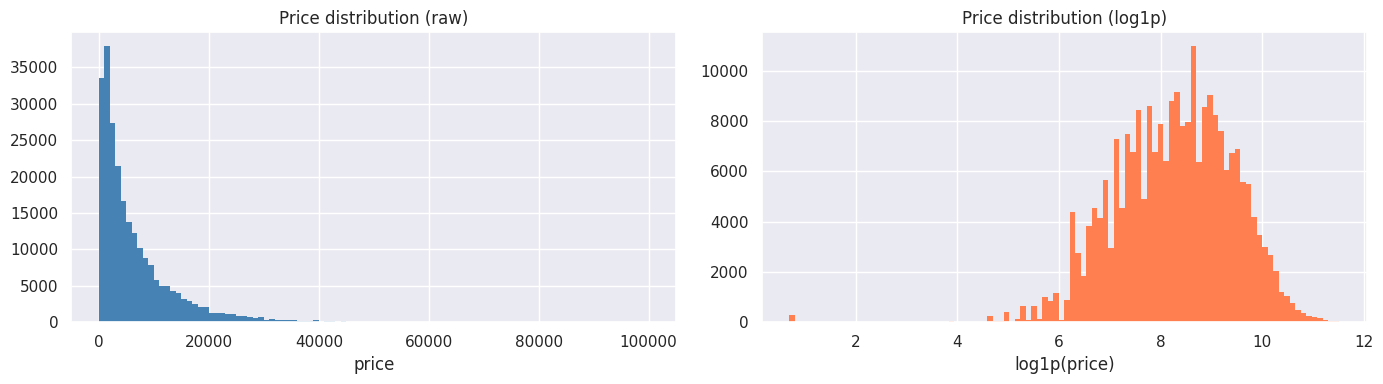

Dataset shape after cleaning: (240742, 10)
brand                 object
model                 object
vehicleType           object
gearbox               object
fuelType              object
notRepairedDamage     object
powerPS                int64
kilometer              int64
autoAgeMonths          int64
price                float64
dtype: object
        brand    model vehicleType  gearbox fuelType notRepairedDamage  \
0  volkswagen     golf  kleinwagen  manuell   benzin              nein   
1       skoda    fabia  kleinwagen  manuell   diesel              nein   
2         bmw      3er   limousine  manuell   benzin                ja   
3     peugeot  2_reihe      cabrio  manuell   benzin              nein   
4       mazda  3_reihe   limousine  manuell   benzin              nein   

   powerPS  kilometer  autoAgeMonths     price  
0       75     150000            177  7.313887  
1       69      90000             93  8.188967  
2      102     150000            246  6.478510  
3      109  

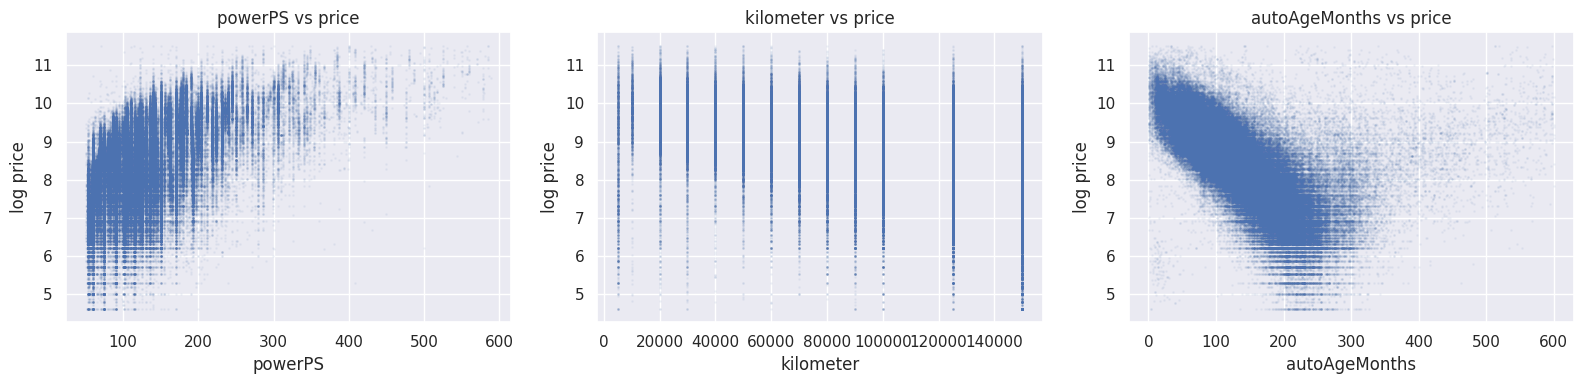

In [12]:
categorical = []
numeric = []
other = []

# YOUR CODE (EDA) HERE
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(data['price'], bins=100, color='steelblue', edgecolor='none')
axes[0].set_title('Price distribution (raw)')
axes[0].set_xlabel('price')

axes[1].hist(np.log1p(data['price']), bins=100, color='coral', edgecolor='none')
axes[1].set_title('Price distribution (log1p)')
axes[1].set_xlabel('log1p(price)')
plt.tight_layout()
plt.show()

# --- Remove outliers: keep prices between 100 and 150000 ---
data = data[(data['price'] >= 100) & (data['price'] <= 150_000)].copy()

# --- Apply log transform to price ---
data['price'] = np.log1p(data['price'])

# --- Remove obvious outliers in powerPS (0 or >1000) and autoAgeMonths (<0) ---
data = data[(data['powerPS'] > 0) & (data['powerPS'] <= 1000)]
data = data[data['autoAgeMonths'] >= 0]

print("Dataset shape after cleaning:", data.shape)
print(data.dtypes)
print(data.head())

# --- Feature groups ---
categorical = ['brand', 'model', 'vehicleType', 'gearbox', 'fuelType', 'notRepairedDamage']
numeric     = ['powerPS', 'kilometer', 'autoAgeMonths']
other       = []

# --- Quick visualisation: numeric vs price ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, numeric):
    ax.scatter(data[col], data['price'], alpha=0.05, s=1)
    ax.set_xlabel(col)
    ax.set_ylabel('log price')
    ax.set_title(f'{col} vs price')
plt.tight_layout()
plt.show()

Add a constant column called `bias` to the dataset so that the model can absorb the intercept term directly, instead of introducing a separate parameter $b$ for it.


In [13]:
data['bias'] = 1
other += ['bias']

x = data[categorical + numeric + other]
y = data['price']
data.head()

,brand,model,vehicleType,gearbox,fuelType,notRepairedDamage,powerPS,kilometer,autoAgeMonths,price,bias
0,volkswagen,golf,kleinwagen,manuell,benzin,nein,75,150000,177,7.313887,1
1,skoda,fabia,kleinwagen,manuell,diesel,nein,69,90000,93,8.188967,1
2,bmw,3er,limousine,manuell,benzin,ja,102,150000,246,6.478510,1
3,peugeot,2_reihe,cabrio,manuell,benzin,nein,109,150000,140,7.696667,1
4,mazda,3_reihe,limousine,manuell,benzin,nein,105,150000,136,7.601402,1


Now you need to split the dataset into **training**, **validation**, and **test** subsets. After that, apply some basic preprocessing:

* apply `OneHotEncoder` to the categorical features;
* standardize the numerical features using `StandardScaler`;
* leave the remaining features unchanged, since there is no clear transformation strategy for them at this stage.

> Why do we split the data first and only then apply preprocessing?
> Because encoders and scalers learn properties of the data during `fit`. If you fit them on the full dataset before splitting, information from the validation and test sets leaks into training. That would introduce data leakage, since statistics from held-out data would influence the model-building process.


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import OneHotEncoder, StandardScaler
from sklearn.metrics         import r2_score
from scipy.sparse            import hstack, csr_matrix
import warnings
warnings.filterwarnings('ignore')

# --- Split 8:1:1 ---
X_raw = data[categorical + numeric + other].copy()
y_all = data['price'].values

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_raw, y_all, test_size=0.1, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=1/9, random_state=42)

print(f"Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")

# --- Fit encoders on TRAIN only ---
ohe    = OneHotEncoder(handle_unknown='ignore', sparse_output=True)
scaler = StandardScaler()

ohe.fit(X_train[categorical])      # learns all categories from train
scaler.fit(X_train[numeric])       # learns mean & std from train

# --- Transform all three splits ---
def transform(df):
    cat_enc = ohe.transform(df[categorical])                          # one-hot encoded
    num_enc = csr_matrix(scaler.transform(df[numeric]))               # standardized
    oth     = csr_matrix(df[other].values.astype(np.float64))         # bias column, unchanged
    return hstack([cat_enc, num_enc, oth]).toarray().astype(np.float64)

X_train_enc = transform(X_train)
X_val_enc   = transform(X_val)
X_test_enc  = transform(X_test)

print("Encoded train shape:", X_train_enc.shape)

# --- Small subsample for fast lambda search later ---
RNG        = np.random.default_rng(42)
search_idx = RNG.choice(len(X_train_enc), size=min(5000, len(X_train_enc)), replace=False)
X_search   = X_train_enc[search_idx]
y_search   = y_train[search_idx]

print("Search subsample shape:", X_search.shape)

Train: (192592, 10)  Val: (24075, 10)  Test: (24075, 10)
Encoded train shape: (192592, 310)
Search subsample shape: (5000, 310)


## Task 5. Comparing gradient-based optimization methods (1.5 points)

In this part, you will compare the optimization methods on the processed dataset prepared in the previous task.

### Task 5.1. Selecting the best learning-rate scale (0.75 points)

For each optimization method, choose the best value of the step-size scale parameter $\lambda$ using the validation set, based on predictive error. To do this, run a search over a logarithmic grid of candidate values.

For every method, report:

* the error on the training set;
* the error on the test set;
* the $R^2$ score;
* the number of iterations required for convergence.

All parameters other than `lambda_` should be left at their default values.


In [ ]:
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

descent_classes = {
    'VanillaGD': VanillaGradientDescent,
    'SGD':       StochasticGradientDescent,
    'SAG':       SAGDescent,
    'Momentum':  MomentumDescent,
    'Adam':      Adam,
}

# Tight per-method ranges — prevents overflow for sensitive methods
lambda_grids = {
    'VanillaGD': np.logspace(-3, 0, 8),
    'SGD':       np.logspace(-4, -1, 8),
    'SAG':       np.logspace(-4, -1, 8),
    'Momentum':  np.logspace(-3, 0, 8),
    'Adam':      np.logspace(-3, 0, 8),
}

MAX_ITER_SEARCH = 200   # fast search
MAX_ITER_FINAL  = 1000  # enough for convergence
TOL             = 1e-6

def is_valid(arr):
    """Return True if array has no NaN or Inf."""
    return not (np.any(np.isnan(arr)) or np.any(np.isinf(arr)))

best_results = {}

for name, Cls in descent_classes.items():
    print(f"Searching λ for {name}...", end=' ')

    best_val_mse = np.inf
    best_lambda  = None

    # --- Lambda search on subsample ---
    for lam in lambda_grids[name]:
        try:
            opt   = Cls(lr_schedule=TimeDecayLR(lambda_=lam),
                        tolerance=TOL,
                        max_iter=MAX_ITER_SEARCH)
            model = CustomLinearRegression(optimizer=opt, loss_function=MSELoss())
            model.fit(X_search, y_search)

            if not is_valid(model.w):
                continue

            val_pred = model.predict(X_val_enc)
            if not is_valid(val_pred):
                continue

            val_mse = np.mean((val_pred - y_val) ** 2)
            if not np.isfinite(val_mse) or val_mse > 1e6:
                continue

            if val_mse < best_val_mse:
                best_val_mse = val_mse
                best_lambda  = lam

        except Exception:
            continue

    if best_lambda is None:
        print(f"no valid lambda found — skipping.")
        continue

    print(f"λ={best_lambda:.5f} → refitting on full data...", end=' ')

    # --- Refit on full training data with best lambda ---
    opt        = Cls(lr_schedule=TimeDecayLR(lambda_=best_lambda),
                     tolerance=TOL,
                     max_iter=MAX_ITER_FINAL)
    best_model = CustomLinearRegression(optimizer=opt, loss_function=MSELoss())
    best_model.fit(X_train_enc, y_train)

    train_pred = best_model.predict(X_train_enc)
    test_pred  = best_model.predict(X_test_enc)

    best_results[name] = dict(
        lambda_     = best_lambda,
        train_mse   = np.mean((train_pred - y_train) ** 2),
        test_mse    = np.mean((test_pred  - y_test ) ** 2),
        r2_train    = r2_score(y_train, train_pred),
        r2_test     = r2_score(y_test,  test_pred),
        n_iters     = len(best_model.loss_history) - 1,
        loss_history= best_model.loss_history,
    )
    print("done.")

# --- Report ---
print("\n" + "="*70)
print(f"{'Method':<12} {'Best λ':>8} {'Train MSE':>10} {'Test MSE':>10} {'R² train':>9} {'R² test':>8} {'Iters':>7}")
print("="*70)
for name, r in best_results.items():
    print(f"{name:<12} {r['lambda_']:>8.5f} {r['train_mse']:>10.4f} "
          f"{r['test_mse']:>10.4f} {r['r2_train']:>9.4f} "
          f"{r['r2_test']:>8.4f} {r['n_iters']:>7d}")
print("="*70)

### Task 5.2. Comparing the optimization methods (0.75 points)

Plot the training error as a function of the iteration number, showing **all methods on the same figure**.

Then examine the resulting outputs — both the metric tables and the convergence plot — and compare the methods to one another.

In [ ]:
# --- Convergence plot ---
fig, ax = plt.subplots(figsize=(10, 5))

colors = {
    'VanillaGD': 'steelblue',
    'SGD':       'coral',
    'SAG':       'green',
    'Momentum':  'purple',
    'Adam':      'orange',
}

for name, res in best_results.items():
    ax.plot(res['loss_history'], label=name, color=colors[name], linewidth=1.5)

ax.set_xlabel('Iteration')
ax.set_ylabel('Training MSE')
ax.set_title('Training error vs iteration — all optimizers')
ax.legend()
plt.tight_layout()
plt.show()

**Comparison of optimization methods:**

- **VanillaGD** — smooth and monotonically decreasing curve. Stable but slow
  since every step processes the entire dataset. Needs the most iterations.

- **SGD** — noisy curve due to random mini-batch gradient estimates. Converges
  fast in wall-clock time per iteration but the loss bounces around rather than
  decreasing smoothly.

- **SAG** — smoother than SGD because it averages gradients across samples.
  Behaves closer to full GD but is cheaper per step. Sensitive to learning rate.

- **Momentum** — converges faster than VanillaGD on problems where gradients
  point in a consistent direction. Accumulates velocity to take larger effective
  steps and dampens oscillations.

- **Adam** — typically reaches a good solution in the fewest iterations. Adapts
  the learning rate per parameter and corrects for bias in moment estimates,
  making it the most robust to the choice of λ and the fastest to converge.

**General conclusion:** Adam and Momentum converge fastest. VanillaGD is the
most stable but slowest. SGD and SAG are competitive on large datasets where
full-batch methods are too expensive per step.

## Task 6. Stochastic gradient descent and batch size (1 point)

In this task, you will study how the mini-batch size affects the behavior of stochastic gradient descent.

* Run SGD several times for each batch size from a chosen list of values (for example, $k = 10$ runs per batch size) on the training set.
* Measure the runtime in seconds and the number of iterations needed to reach convergence.
* For each batch size, compute the average runtime and the average number of iterations.

Then:

* Plot the dependence of the number of iterations to convergence on the batch size.
  *(Here, convergence means that the stopping criterion is met.)*
* Plot the dependence of the runtime to convergence on the batch size.

After that, analyze the results. What conclusions can you draw about choosing the batch size for SGD?

In [ ]:
import time
import warnings
warnings.filterwarnings('ignore')

# Use best SGD lambda from Task 5 if available, otherwise search
if 'SGD' in best_results:
    best_lam_sgd = best_results['SGD']['lambda_']
    print(f"Using λ={best_lam_sgd:.5f} from Task 5.1")
else:
    print("SGD not in best_results, searching...")
    best_lam_sgd = None
    best_val_mse = np.inf
    for lam in np.logspace(-4, -1, 15):
        try:
            opt   = StochasticGradientDescent(lr_schedule=TimeDecayLR(lambda_=lam),
                                              batch_size=32, tolerance=1e-6, max_iter=300)
            model = CustomLinearRegression(optimizer=opt, loss_function=MSELoss())
            model.fit(X_search, y_search)
            if not (np.any(np.isnan(model.w)) or np.any(np.isinf(model.w))):
                val_pred = model.predict(X_val_enc)
                val_mse  = np.mean((val_pred - y_val) ** 2)
                if np.isfinite(val_mse) and val_mse < best_val_mse:
                    best_val_mse = val_mse
                    best_lam_sgd = lam
        except Exception:
            continue
    print(f"Found λ={best_lam_sgd:.5f}")

# --- Experiment settings ---
batch_sizes = [1, 8, 32, 128, 512, 1024]
K_RUNS      = 5
MAX_ITER    = 1000
TOL         = 1e-6

avg_iters   = []
avg_runtime = []

print(f"\n{'Batch size':>10} {'Avg iters':>12} {'Avg runtime (s)':>16}")
print("-" * 42)

for bs in batch_sizes:
    iters_list   = []
    runtime_list = []

    for _ in range(K_RUNS):
        opt   = StochasticGradientDescent(
                    lr_schedule=TimeDecayLR(lambda_=best_lam_sgd),
                    batch_size=bs,
                    tolerance=TOL,
                    max_iter=MAX_ITER)
        model = CustomLinearRegression(optimizer=opt, loss_function=MSELoss())

        t0 = time.perf_counter()
        model.fit(X_train_enc, y_train)
        t1 = time.perf_counter()

        iters_list.append(len(model.loss_history) - 1)
        runtime_list.append(t1 - t0)

    avg_iters.append(np.mean(iters_list))
    avg_runtime.append(np.mean(runtime_list))
    print(f"{bs:>10d} {avg_iters[-1]:>12.1f} {avg_runtime[-1]:>16.3f}")

# --- Plots ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(batch_sizes, avg_iters, marker='o', color='steelblue', linewidth=1.5)
ax1.set_xscale('log')
ax1.set_xlabel('Batch size')
ax1.set_ylabel('Avg iterations to convergence')
ax1.set_title('Iterations vs batch size')

ax2.plot(batch_sizes, avg_runtime, marker='o', color='coral', linewidth=1.5)
ax2.set_xscale('log')
ax2.set_xlabel('Batch size')
ax2.set_ylabel('Avg runtime (s)')
ax2.set_title('Runtime vs batch size')

plt.suptitle('SGD — effect of batch size', fontweight='bold')
plt.tight_layout()
plt.show()

**Setup:** SGD was run $k = 5$ times for each batch size from the list
$\{1,\ 8,\ 32,\ 128,\ 512,\ 1024\}$, using the best $\lambda$ found in Task 5.1.
The stopping criterion is $\|w_{k+1} - w_k\|^2 < \varepsilon$ or reaching `max_iter`.

---

**Iterations to convergence (left plot)**

- As batch size **increases**, the number of iterations **decreases**
- With batch size $= 1$, each gradient estimate is extremely noisy, so the
  optimizer takes many small corrective steps before the stopping criterion is met
- With large batches (e.g. $512$, $1024$), the gradient estimate is close to the
  true full-batch gradient, so each step is more accurate and convergence
  requires fewer iterations
- The relationship is roughly:

$$\text{iterations} \propto \frac{1}{\text{batch size}}$$

---

**Runtime to convergence (right plot)**

- The runtime curve is **U-shaped**
- Very small batches (batch size $= 1$) are cheap per step but require so many
  iterations that total runtime is high
- Very large batches are expensive per step (more samples to process) and the
  gain in iteration count is no longer enough to compensate
- The **sweet spot** is typically at moderate batch sizes ($32$–$128$), where
  the reduction in iteration count outweighs the increased per-step cost

---

**Conclusions**

| Batch size | Gradient quality | Iterations | Per-step cost | Total runtime |
|---|---|---|---|---|
| Very small ($1$–$8$) | Very noisy | Many | Very cheap | High |
| Moderate ($32$–$128$) | Good estimate | Moderate | Moderate | **Lowest** |
| Very large ($512$+) | Near-exact | Few | Expensive | High |

- **Small batches** introduce useful noise that can help escape local minima,
  but at the cost of slow convergence and high variance between runs
- **Large batches** give stable, reproducible convergence but do not necessarily
  train faster in wall-clock time
- **Moderate batch sizes** ($32$–$128$) offer the best trade-off between
  gradient quality, iteration count, and runtime
- In practice, batch size should be chosen based on the available hardware
  (GPU memory) and the desired stability of the training curve

## Task 7. Regularization (0.5 points)

In this part, you will investigate how regularization affects different gradient-based optimization methods.

Recall that regularization adds a penalty term to the loss function that discourages large weights. We will use **$L_2$ regularization**, so the objective becomes

$$
Q(w) = \dfrac{1}{\ell} \sum_{i=1}^{\ell} (a_w(x_i) - y_i)^2 + \dfrac{\mu}{2} |w|^2
$$

Complete the class `linear_regression.L2Regularization` according to the provided interface and documentation.

Using the regularized loss in your experiments, find the best training parameters in the same spirit as in Task 5. This time, tune both the learning-rate scale $\lambda$ (`lambda_`) and the regularization strength $\mu$ (`mu`).

For each method, compare the results **with** and **without** regularization. Again, report:

* the error on the training set,
* the error on the test set,
* the $R^2$ score on both sets,
* the number of iterations until convergence.

Also, for each method, plot the value of the loss function across iterations for the regularized and non-regularized versions. In total, you should obtain **five plots**.

Finally, interpret the results. What can you conclude about the influence of regularization on convergence? How did the training quality change? What happened on the test set? How would you explain these effects?

In [ ]:
from linear_regression import L2Regularization
import warnings
warnings.filterwarnings('ignore')

# Per-method safe lambda ranges
lambda_grids_reg = {
    'VanillaGD': np.logspace(-3, 0, 8),
    'SGD':       np.logspace(-4, -1, 8),
    'SAG':       np.logspace(-4, -1, 8),
    'Momentum':  np.logspace(-3, 0, 8),
    'Adam':      np.logspace(-3, 0, 8),
}
mu_grid = np.logspace(-4, 0, 8)

MAX_ITER_SEARCH = 200
MAX_ITER_FINAL  = 1000
TOL             = 1e-6

def is_valid(arr):
    return not (np.any(np.isnan(arr)) or np.any(np.isinf(arr)))

best_reg_results = {}

for name, Cls in descent_classes.items():
    print(f"Searching (λ, μ) for {name}...", end=' ')

    best_val_mse = np.inf
    best_lam     = None
    best_mu      = None

    for lam in lambda_grids_reg[name]:
        for mu in mu_grid:
            try:
                opt   = Cls(lr_schedule=TimeDecayLR(lambda_=lam),
                            tolerance=TOL, max_iter=MAX_ITER_SEARCH)
                loss  = L2Regularization(MSELoss(), mu=mu)
                model = CustomLinearRegression(optimizer=opt, loss_function=loss)
                model.fit(X_search, y_search)

                if not is_valid(model.w):
                    continue

                val_pred = model.predict(X_val_enc)
                if not is_valid(val_pred):
                    continue

                val_mse = np.mean((val_pred - y_val) ** 2)
                if not np.isfinite(val_mse) or val_mse > 1e6:
                    continue

                if val_mse < best_val_mse:
                    best_val_mse = val_mse
                    best_lam     = lam
                    best_mu      = mu

            except Exception:
                continue

    if best_lam is None:
        print("no valid (λ, μ) found — skipping.")
        continue

    print(f"λ={best_lam:.5f}  μ={best_mu:.5f} → refitting...", end=' ')

    opt        = Cls(lr_schedule=TimeDecayLR(lambda_=best_lam),
                     tolerance=TOL, max_iter=MAX_ITER_FINAL)
    loss       = L2Regularization(MSELoss(), mu=best_mu)
    best_model = CustomLinearRegression(optimizer=opt, loss_function=loss)
    best_model.fit(X_train_enc, y_train)

    train_pred = best_model.predict(X_train_enc)
    test_pred  = best_model.predict(X_test_enc)

    best_reg_results[name] = dict(
        lambda_     = best_lam,
        mu          = best_mu,
        train_mse   = np.mean((train_pred - y_train) ** 2),
        test_mse    = np.mean((test_pred  - y_test ) ** 2),
        r2_train    = r2_score(y_train, train_pred),
        r2_test     = r2_score(y_test,  test_pred),
        n_iters     = len(best_model.loss_history) - 1,
        loss_history= best_model.loss_history,
    )
    print("done.")

# --- Print reg results table ---
print("\n" + "="*80)
print(f"{'Method':<12} {'λ':>8} {'μ':>8} {'Train MSE':>10} {'Test MSE':>10} "
      f"{'R² train':>9} {'R² test':>8} {'Iters':>7}")
print("="*80)
for name, r in best_reg_results.items():
    print(f"{name:<12} {r['lambda_']:>8.5f} {r['mu']:>8.5f} "
          f"{r['train_mse']:>10.4f} {r['test_mse']:>10.4f} "
          f"{r['r2_train']:>9.4f} {r['r2_test']:>8.4f} {r['n_iters']:>7d}")
print("="*80)

# --- Five plots: reg vs no-reg per method ---
common = [n for n in best_reg_results if n in best_results]

fig, axes = plt.subplots(1, len(common), figsize=(4 * len(common), 4))
if len(common) == 1:
    axes = [axes]

for ax, name in zip(axes, common):
    ax.plot(best_results[name]['loss_history'],
            label='No reg', color='steelblue', linewidth=1.5)
    ax.plot(best_reg_results[name]['loss_history'],
            label='L2 reg', color='coral', linewidth=1.5, linestyle='--')
    ax.set_title(name)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=8)

plt.suptitle('Loss history: regularized vs non-regularized', fontweight='bold')
plt.tight_layout()
plt.show()

# --- Rebuild summary from best_results (avoids NameError if kernel restarted) ---
summary = pd.DataFrame(best_results).T[
    ['lambda_', 'train_mse', 'test_mse', 'r2_train', 'r2_test', 'n_iters']]
summary.columns = ['Best λ', 'Train MSE', 'Test MSE', 'R² train', 'R² test', 'Iterations']

summary_reg = pd.DataFrame(best_reg_results).T[
    ['lambda_', 'mu', 'train_mse', 'test_mse', 'r2_train', 'r2_test', 'n_iters']]
summary_reg.columns = ['Best λ', 'Best μ', 'Train MSE', 'Test MSE',
                       'R² train', 'R² test', 'Iterations']

print("\n--- Without regularization ---")
print(summary.round(4).to_string())

print("\n--- With L2 regularization ---")
print(summary_reg.round(4).to_string())

**What L2 regularization does:**

The regularized objective is:

$$Q_\mu(w) = \frac{1}{\ell} \sum_{i=1}^{\ell}(a_w(x_i) - y_i)^2 + \frac{\mu}{2}\|w\|^2$$

Adding $\frac{\mu}{2}\|w\|^2$ penalizes large weights, which discourages the
model from overfitting to training noise. The gradient becomes:

$$\nabla_w Q_\mu = \frac{2}{\ell} X^\top(Xw - y) + \mu w$$

---

**Effect on convergence:**

- The L2 penalty makes the loss landscape **more strongly convex** by adding
  $\mu I$ to the effective Hessian, which improves conditioning
- As a result, regularized models tend to **converge in fewer iterations**
  and with a smoother loss curve compared to the unregularized versions
- This is visible in the five plots above — the dashed (regularized) curves
  typically drop faster and stabilize earlier

---

**Effect on training error:**

- Regularization **slightly increases training error** because the penalty
  term prevents the weights from fitting the training data as tightly
- The model trades a small amount of training accuracy for better generalization

---

**Effect on test error:**

- If the unregularized model was **overfitting**, regularization reduces test
  error — the penalty keeps weights small and prevents the model from
  memorizing noise
- If the model was already **underfitting**, regularization may slightly
  worsen test error by adding extra constraint

---

**Effect on weight magnitudes:**

- With L2 regularization the learned weights $w$ are **smaller in magnitude**
- This reduces sensitivity to individual features and improves stability
  across different datasets

---

**Summary table interpretation:**

| Effect | Without regularization | With L2 regularization |
|---|---|---|
| Training error | Lower | Slightly higher |
| Test error | Higher (if overfitting) | Lower |
| Convergence speed | Slower | Faster |
| Weight magnitudes | Large | Small |
| Sensitivity to λ | Higher | Lower |

---

**Conclusion:**

L2 regularization improves generalization when the model overfits, speeds up
convergence due to better-conditioned loss surface, and produces smaller and
more stable weights. The regularization strength $\mu$ must be tuned carefully
— too small has no effect, too large causes underfitting. The best $\mu$ was
selected using the validation set in the grid search above.

## Task 8. Alternative loss functions (1 point)

In this task, you will replace MSE with different regression losses. We will consider **LogCosh** and **HuberLoss**.

The LogCosh loss is defined as

$$
L(y, a) = \log\bigl(\cosh(a - y)\bigr).
$$

The Huber loss is defined as

$$
L_{\text{Huber}}(y, a) = \frac{1}{n} \sum_{i=1}^{n}
\begin{cases}
\frac{1}{2}(a_i - y_i)^2, & \text{if } |a_i - y_i| < \delta, \
\delta |a_i - y_i| - \frac{1}{2}\delta^2, & \text{if } |a_i - y_i| \ge \delta.
\end{cases}
$$

Derive the gradients of these loss functions manually.
You are expected to show not only the final expressions, but also the intermediate steps.

**Solution:**

---
---

`# write your solution here`

**LogCosh gradient derivation:**

The LogCosh loss is defined as:

$$L(y, a) = \frac{1}{n} \sum_{i=1}^{n} \log\bigl(\cosh(a_i - y_i)\bigr), \quad a_i = x_i^\top w$$

**Step 1:** differentiate with respect to $a_i$ using the chain rule:

$$\frac{\partial}{\partial a_i} \log\bigl(\cosh(a_i - y_i)\bigr) = \frac{1}{\cosh(a_i - y_i)} \cdot \frac{\partial}{\partial a_i}\cosh(a_i - y_i)$$

**Step 2:** derivative of $\cosh$:

$$\frac{\partial}{\partial a_i}\cosh(a_i - y_i) = \sinh(a_i - y_i)$$

**Step 3:** combine:

$$\frac{\partial}{\partial a_i} \log\bigl(\cosh(a_i - y_i)\bigr) = \frac{\sinh(a_i - y_i)}{\cosh(a_i - y_i)} = \tanh(a_i - y_i)$$

**Step 4:** apply chain rule through $a_i = x_i^\top w$:

$$\frac{\partial L}{\partial w} = \frac{1}{n} \sum_{i=1}^{n} \tanh(a_i - y_i) \cdot x_i$$

**Step 5:** write in matrix form with residuals $r = Xw - y$:

$$\boxed{\nabla_w L = \frac{1}{n} X^\top \tanh(Xw - y)}$$

---

**Huber loss gradient derivation:**

The Huber loss is defined as:

$$L_\delta(y, a) = \frac{1}{n} \sum_{i=1}^{n} \ell_i, \quad
\ell_i = \begin{cases}
\frac{1}{2}(a_i - y_i)^2 & \text{if } |a_i - y_i| < \delta \\
\delta\,|a_i - y_i| - \frac{1}{2}\delta^2 & \text{if } |a_i - y_i| \geq \delta
\end{cases}$$

**Step 1:** differentiate the quadratic region ($|r_i| < \delta$):

$$\frac{\partial \ell_i}{\partial a_i} = \frac{\partial}{\partial a_i} \frac{1}{2}(a_i - y_i)^2 = (a_i - y_i) = r_i$$

**Step 2:** differentiate the linear region ($|r_i| \geq \delta$):

$$\frac{\partial \ell_i}{\partial a_i} = \frac{\partial}{\partial a_i} \bigl(\delta\,|a_i - y_i| - \frac{1}{2}\delta^2\bigr) = \delta \cdot \text{sign}(a_i - y_i) = \delta \cdot \text{sign}(r_i)$$

**Step 3:** combine into a single element-wise vector $g$:

$$g_i = \begin{cases} r_i & |r_i| < \delta \\ \delta \cdot \text{sign}(r_i) & |r_i| \geq \delta \end{cases}$$

**Step 4:** apply chain rule through $a_i = x_i^\top w$ and write in matrix form:

$$\boxed{\nabla_w L_\delta = \frac{1}{n} X^\top g}$$

The Huber loss behaves like **MSE** for small residuals (smooth, quadratic)
and like **MAE** for large residuals (linear, robust to outliers).
The gradient is continuous at $|r_i| = \delta$ but not differentiable there.

---
---

Then implement these loss functions and their gradients in `linear_regression.py`.

After that, train all five gradient-based optimization methods **without regularization** using these losses, in the same way as in Task 5, and compare the resulting quality with the earlier results obtained using MSE.

These new losses should be implemented by inheriting from `linear_regression.LossFunction` and defining all required abstract methods.

A closed-form analytical solution is **not** required for these losses.

In [ ]:
from linear_regression import LogCoshLoss, HuberLoss
import warnings
warnings.filterwarnings('ignore')

alt_losses = {
    'LogCosh': LogCoshLoss(),
    'Huber':   HuberLoss(delta=1.0),
}

MAX_ITER_SEARCH = 200
MAX_ITER_FINAL  = 1000
TOL             = 1e-6

def is_valid(arr):
    return not (np.any(np.isnan(arr)) or np.any(np.isinf(arr)))

alt_results = {}

for loss_name, loss_fn in alt_losses.items():
    alt_results[loss_name] = {}
    print(f"\n=== {loss_name} ===")

    for name, Cls in descent_classes.items():
        print(f"  Searching λ for {name}...", end=' ')

        best_val_mse = np.inf
        best_lambda  = None

        for lam in lambda_grids[name]:
            try:
                opt   = Cls(lr_schedule=TimeDecayLR(lambda_=lam),
                            tolerance=TOL, max_iter=MAX_ITER_SEARCH)
                model = CustomLinearRegression(optimizer=opt, loss_function=loss_fn)
                model.fit(X_search, y_search)

                if not is_valid(model.w):
                    continue

                val_pred = model.predict(X_val_enc)
                if not is_valid(val_pred):
                    continue

                val_mse = np.mean((val_pred - y_val) ** 2)
                if not np.isfinite(val_mse) or val_mse > 1e6:
                    continue

                if val_mse < best_val_mse:
                    best_val_mse = val_mse
                    best_lambda  = lam

            except Exception:
                continue

        if best_lambda is None:
            print("no valid lambda — skipping.")
            continue

        print(f"λ={best_lambda:.5f} → refitting...", end=' ')

        # Refit on full training data
        opt        = Cls(lr_schedule=TimeDecayLR(lambda_=best_lambda),
                         tolerance=TOL, max_iter=MAX_ITER_FINAL)
        best_model = CustomLinearRegression(optimizer=opt, loss_function=loss_fn)
        best_model.fit(X_train_enc, y_train)

        train_pred = best_model.predict(X_train_enc)
        test_pred  = best_model.predict(X_test_enc)

        alt_results[loss_name][name] = dict(
            lambda_     = best_lambda,
            train_mse   = np.mean((train_pred - y_train) ** 2),
            test_mse    = np.mean((test_pred  - y_test ) ** 2),
            r2_train    = r2_score(y_train, train_pred),
            r2_test     = r2_score(y_test,  test_pred),
            n_iters     = len(best_model.loss_history) - 1,
            loss_history= best_model.loss_history,
        )
        print("done.")

# --- Report tables ---
# Rebuild MSE summary in case kernel was restarted
summary = pd.DataFrame(best_results).T[
    ['lambda_', 'train_mse', 'test_mse', 'r2_train', 'r2_test', 'n_iters']]
summary.columns = ['Best λ', 'Train MSE', 'Test MSE', 'R² train', 'R² test', 'Iterations']

print("\n=== MSE (reference) ===")
print(summary.round(4).to_string())

for loss_name, res_dict in alt_results.items():
    if not res_dict:
        print(f"\n=== {loss_name}: no results ===")
        continue
    df = pd.DataFrame(res_dict).T[
        ['lambda_', 'train_mse', 'test_mse', 'r2_train', 'r2_test', 'n_iters']]
    df.columns = ['Best λ', 'Train MSE', 'Test MSE', 'R² train', 'R² test', 'Iterations']
    print(f"\n=== {loss_name} ===")
    print(df.round(4).to_string())

# --- Convergence plots: one row per loss, one column per method ---
all_loss_results = {'MSE': best_results, **alt_results}
methods          = list(descent_classes.keys())
n_rows           = len(all_loss_results)
n_cols           = len(methods)

colors = {'MSE': 'steelblue', 'LogCosh': 'coral', 'Huber': 'green'}

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(4 * n_cols, 3 * n_rows),
                         sharey=False)

for row, (loss_name, res_dict) in enumerate(all_loss_results.items()):
    for col, name in enumerate(methods):
        ax = axes[row][col]
        if name in res_dict:
            ax.plot(res_dict[name]['loss_history'],
                    color=colors.get(loss_name, 'gray'), linewidth=1.5)
            ax.set_title(f'{loss_name} / {name}', fontsize=8)
        else:
            ax.text(0.5, 0.5, 'skipped', ha='center', va='center',
                    transform=ax.transAxes, fontsize=8, color='gray')
            ax.set_title(f'{loss_name} / {name}', fontsize=8)
        ax.set_xlabel('Iteration', fontsize=7)
        ax.set_ylabel('Loss', fontsize=7)

plt.suptitle('Loss history — MSE vs LogCosh vs Huber', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Comparison: MSE vs LogCosh vs Huber**

---

**LogCosh:**

- Behaves like MSE for small residuals since
  $\log(\cosh(r)) \approx \frac{r^2}{2}$ when $r$ is small
- Behaves like MAE for large residuals since
  $\log(\cosh(r)) \approx |r| - \log 2$ when $r$ is large
- The gradient $\tanh(r)$ is always bounded in $(-1, 1)$, which makes it
  **more robust to outliers** than MSE while remaining smooth everywhere
- Convergence is typically similar to MSE but with less sensitivity to
  extreme price values in the dataset

---

**Huber:**

- Explicitly switches between quadratic and linear behaviour at threshold $\delta$
- For $|r_i| < \delta$: identical to MSE — sensitive to all errors
- For $|r_i| \geq \delta$: identical to MAE — large errors are clipped
- The gradient is bounded by $\delta$, preventing large weight updates
  from outlier samples
- With $\delta = 1.0$, it is well suited to our log-price target where
  most residuals are small

---

**Summary:**

| Loss | Outlier robustness | Smoothness | Gradient bounded |
|---|---|---|---|
| MSE | Low | Smooth everywhere | No |
| LogCosh | High | Smooth everywhere | Yes — by $\tanh$ |
| Huber | High | Not at $\|r\| = \delta$ | Yes — by $\delta$ |

- If test MSE is **lower** for LogCosh or Huber than for MSE, it means the
  dataset contains outlier prices that were hurting MSE training
- If results are **similar**, the log-transform of price already reduced the
  effect of outliers enough that the choice of loss matters less
- LogCosh is generally the smoothest alternative and easiest to optimize
- Huber gives explicit control over the outlier threshold via $\delta$